# Task 5: Exploratory Data Analysis (EDA) – Titanic Dataset

## Objective

The objective of this analysis is to explore the Titanic dataset using statistical and visual techniques to identify patterns, trends, relationships, and anomalies.

## Tools Used

- Python
- Pandas
- Matplotlib
- Seaborn

## Dataset

The dataset used for this analysis is the Titanic `train.csv` dataset.

## Analysis Performed

The following exploratory techniques are used:

- Dataset structure and information
- Descriptive statistics
- Categorical value counts
- Missing value analysis
- Histograms
- Countplots
- Boxplots
- Scatterplots
- Correlation heatmap
- Pairplot
- Survival rate analysis
- Family-size analysis


## 1. Import Libraries and Load Dataset


In [1]:
import pandas as pd

df = pd.read_csv("train.csv")

df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Dataset Overview


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Observation

The Titanic dataset contains 891 passenger records and 12 columns. The dataset includes numerical and categorical variables. Missing values are present mainly in the `Age`, `Cabin`, and `Embarked` columns. The average passenger age is approximately 29.7 years, and approximately 38.4% of passengers survived.


## 3. Categorical Variable Analysis


### 3.1 Gender Distribution


In [4]:
df["Sex"].value_counts()


Sex
male      577
female    314
Name: count, dtype: int64

### Observation

The dataset contains 577 male passengers and 314 female passengers. Therefore, male passengers make up the larger proportion of the dataset.


### 3.2 Survival Distribution


In [5]:
df["Survived"].value_counts()


Survived
0    549
1    342
Name: count, dtype: int64

### Observation

Out of 891 passengers, 549 did not survive and 342 survived. Therefore, approximately 38.4% of passengers survived, while 61.6% did not survive.


### 3.3 Passenger Class Distribution


In [6]:
df["Pclass"].value_counts()


Pclass
3    491
1    216
2    184
Name: count, dtype: int64

### Observation

The majority of passengers belonged to 3rd class, with 491 passengers. There were 216 passengers in 1st class and 184 passengers in 2nd class.


## 4. Missing Value Analysis


In [7]:
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df.dtypes


PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

### Observation

Missing values are present in three columns. The `Cabin` column has the highest number of missing values with 687, followed by `Age` with 177 and `Embarked` with 2. The `Cabin` column has a substantial amount of missing data and may require special consideration in further analysis.


## 5. Duplicate Value Analysis


In [28]:
df.duplicated().sum()


np.int64(0)

Observation
The dataset contains no duplicate rows.

### 6.1 Survival Distribution


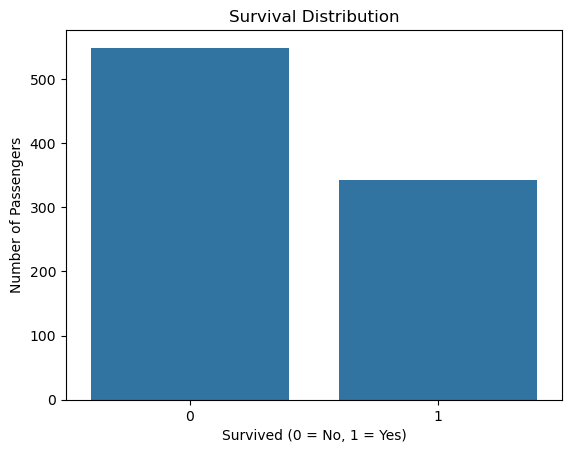

In [11]:
sns.countplot(data=df, x="Survived")

plt.title("Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()


### Observation

The graph shows that 549 passengers did not survive, while 342 passengers survived. Therefore, the majority of passengers did not survive. Approximately 38.4% of passengers survived, while 61.6% did not survive.


### 6.2 Age Distribution


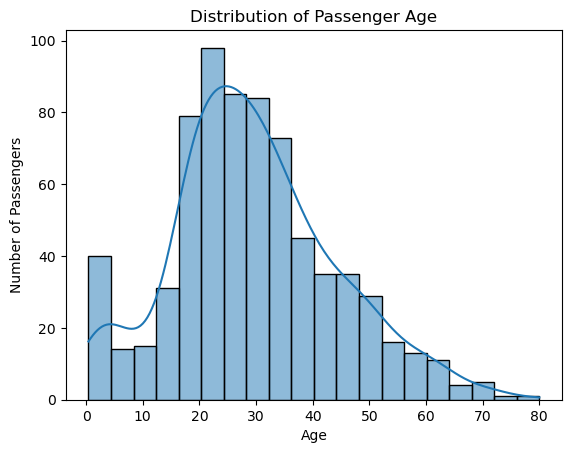

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(data=df, x="Age", bins=20, kde=True)

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()


### Observation

The age distribution is concentrated mainly between approximately 20 and 40 years. There are fewer very young and older passengers. The distribution also contains missing values because 177 passengers do not have recorded ages.


### 6.3 Fare Distribution


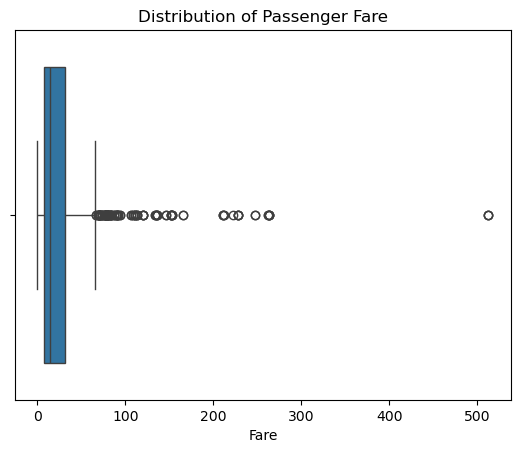

In [15]:
sns.boxplot(data=df, x="Fare")

plt.title("Distribution of Passenger Fare")
plt.xlabel("Fare")

plt.show()


### Observation

The fare distribution is highly right-skewed. Most passengers paid relatively low fares, while a small number of passengers paid very high fares. Several potential outliers are visible in the boxplot. The maximum fare was approximately 512.33, while the median fare was approximately 14.45.


## 7. Bivariate Analysis

### 7.1 Survival by Gender


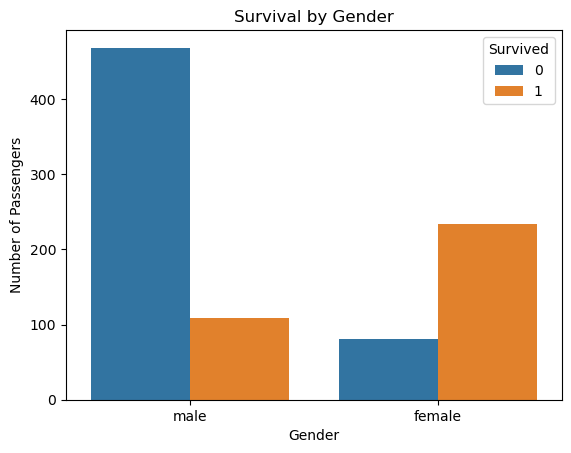

In [12]:
sns.countplot(data=df, x="Sex", hue="Survived")

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()



### 7.2 Survival by Passenger Class


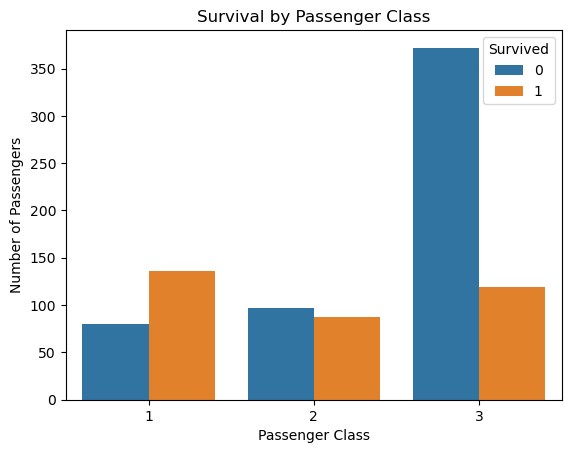

In [13]:
sns.countplot(data=df, x="Pclass", hue="Survived")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()


### Observation

Survival varied considerably across passenger classes. First-class passengers had the highest survival rate at approximately 63.0%, followed by second-class passengers at approximately 47.3%. Third-class passengers had the lowest survival rate at approximately 24.2%. This indicates a strong association between passenger class and survival.


### 7.3 Age Distribution by Survival


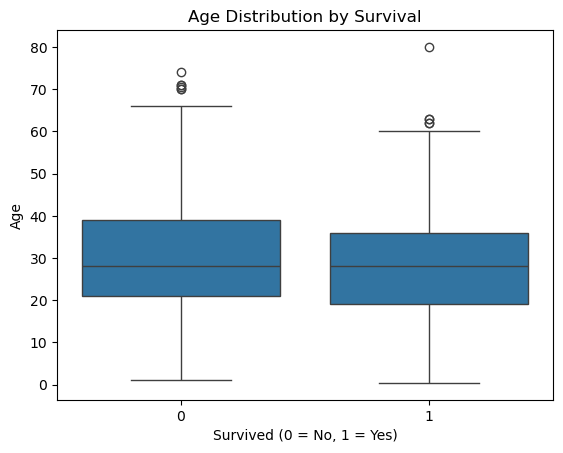

In [14]:
sns.boxplot(data=df, x="Survived", y="Age")

plt.title("Age Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.show()


### Observation

The age distributions of survivors and non-survivors overlap considerably. This suggests that age alone does not clearly distinguish between passengers who survived and those who did not. However, there are some differences in the median ages and overall distributions of the two groups. The analysis should also consider the missing values in the Age column.


### 7.4 Fare Distribution by Survival


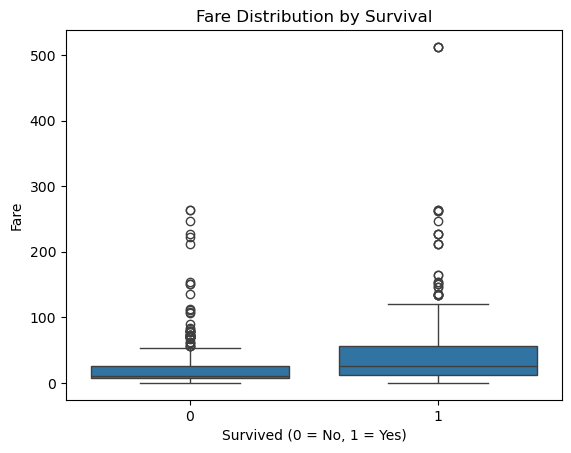

In [16]:
sns.boxplot(data=df, x="Survived", y="Fare")

plt.title("Fare Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Fare")

plt.show()


### Observation

Passengers who survived generally paid higher fares than passengers who did not survive. The median fare for survivors is higher, suggesting a relationship between fare and survival. The plot also shows several high-fare outliers.


### 7.5 Survival by Embarkation Port


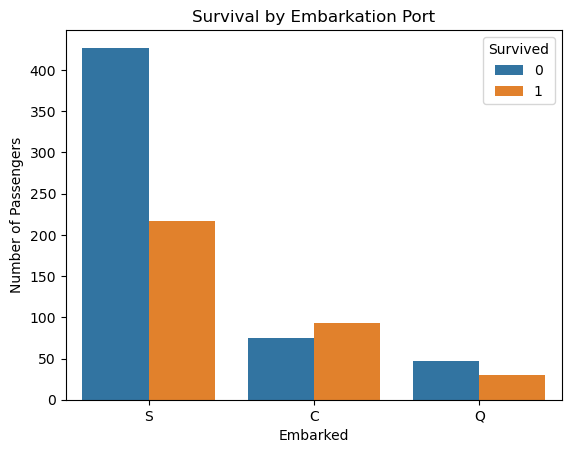

In [26]:
sns.countplot(data=df, x="Embarked", hue="Survived")

plt.title("Survival by Embarkation Port")
plt.xlabel("Embarked")
plt.ylabel("Number of Passengers")

plt.show()


### Observation

Survival varied across the three embarkation ports. Passengers who embarked from port C had the highest survival rate at approximately 55.4%, followed by port Q at approximately 39.0% and port S at approximately 33.7%. This suggests an association between embarkation port and survival, although the difference may also be influenced by other factors such as passenger class and gender.


## 8. Multivariate Analysis

### 8.1 Correlation Heatmap


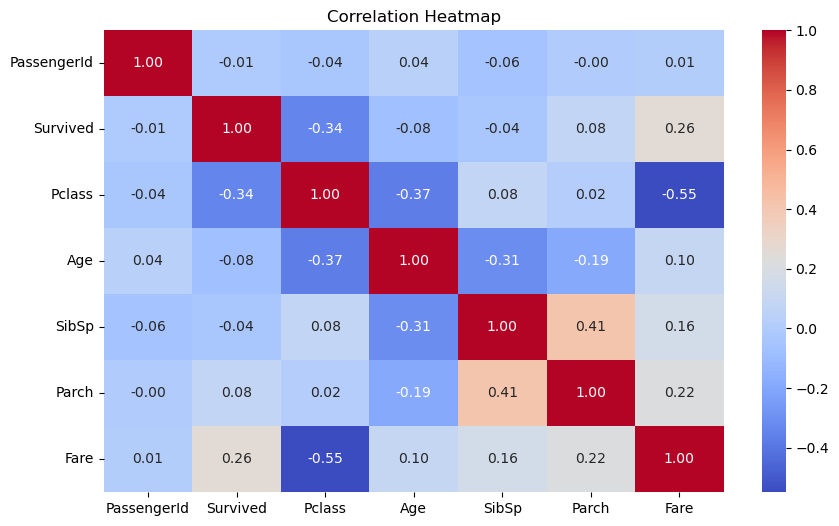

In [17]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()


### Observation

The heatmap shows the correlation between the numerical variables in the Titanic dataset. `Pclass` has a negative correlation with `Survived`, indicating that higher class numbers (representing lower passenger classes) are associated with lower survival. `Fare` has a positive correlation with `Survived`, suggesting that passengers who paid higher fares generally had better survival outcomes. Most other numerical variables show relatively weak correlations with survival.


### 8.2 Pairplot


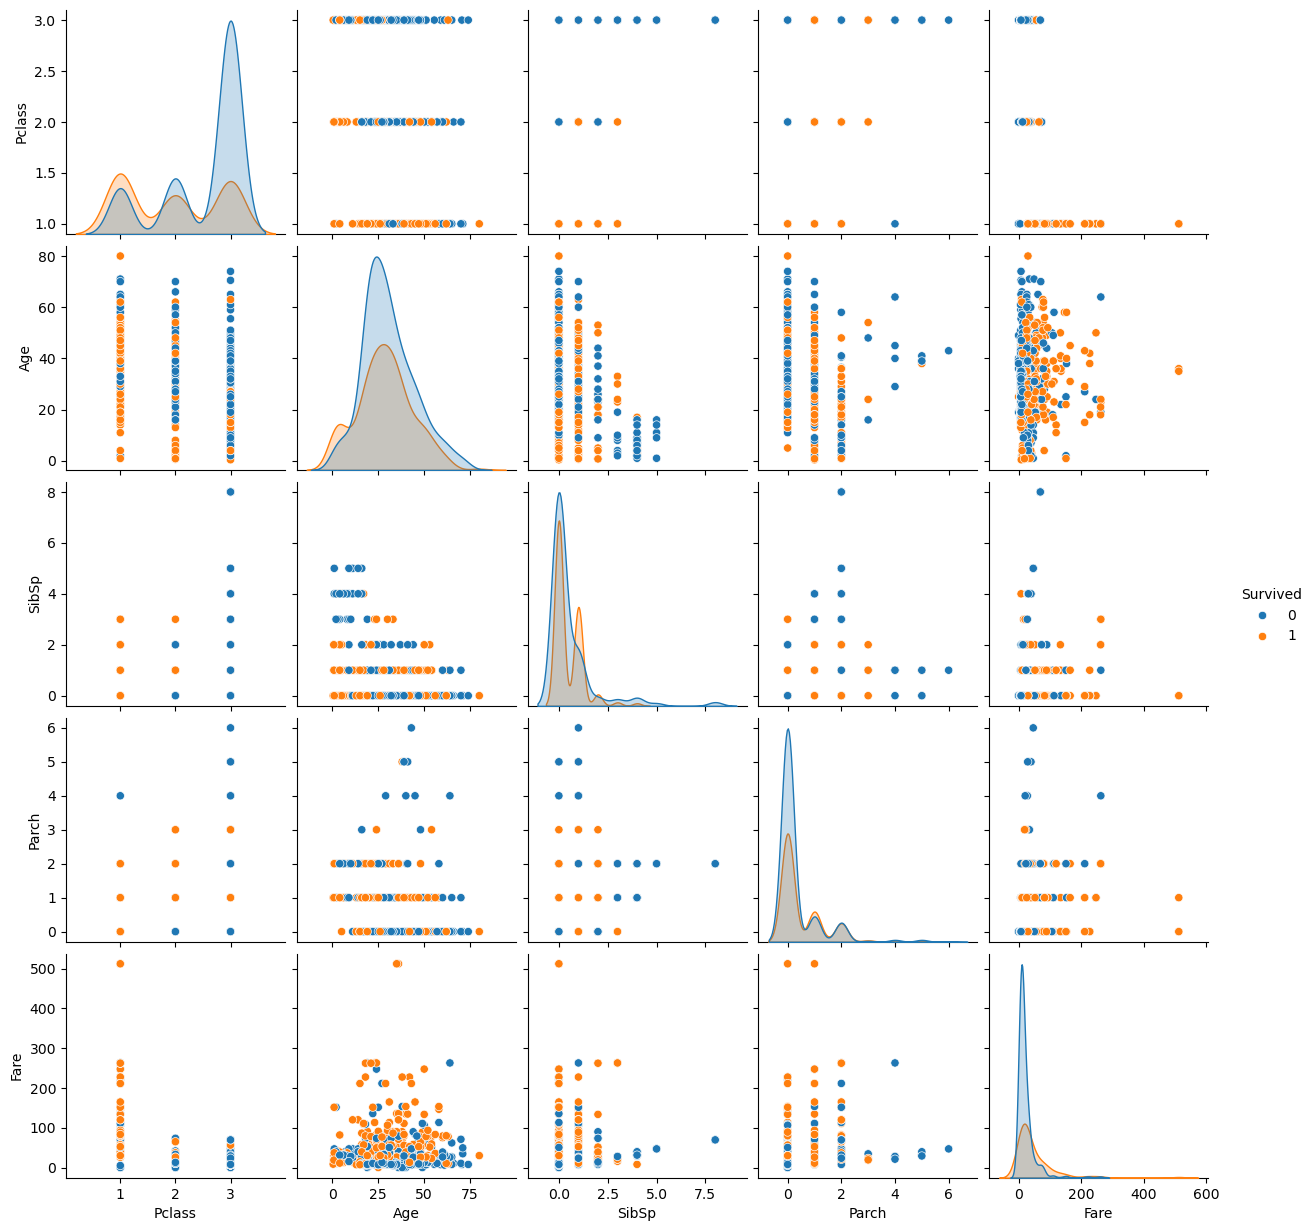

In [19]:
sns.pairplot(
    df[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]],
    hue="Survived"
)

plt.show()


### Observation

The pairplot shows relationships among the numerical variables and helps identify patterns and distributions for survivors and non-survivors. `Pclass` and `Fare` show noticeable relationships with survival, while `Age` shows considerable overlap between the two survival groups. The plot also highlights the presence of extreme fare values.


### 8.3 Age vs Fare by Survival


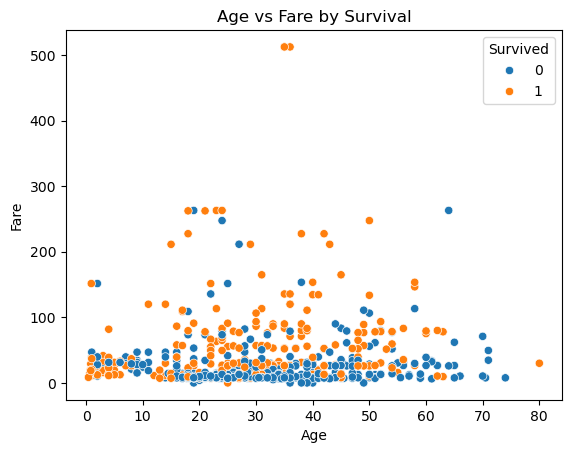

In [18]:
sns.scatterplot(data=df, x="Age", y="Fare", hue="Survived")

plt.title("Age vs Fare by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()


### Observation

The scatterplot shows the relationship between passenger age and fare, with different colors representing survival status. There is no clear linear relationship between age and fare. However, passengers who paid higher fares appear in both survival groups, and some high-fare observations are visible as outliers.


#### Survival Rate by Gender


In [20]:
df.groupby("Sex")["Survived"].mean() * 100


Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

#### Survival Rate by Passenger Class


In [21]:
df.groupby("Pclass")["Survived"].mean() * 100


Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

### 9.1 Creating Family Size


In [22]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

df[["SibSp", "Parch", "FamilySize"]].head()


,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


### 9.2 Survival Rate by Family Size


In [23]:
df.groupby("FamilySize")["Survived"].mean() * 100


FamilySize
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: Survived, dtype: float64

#### Survival Rate by Family Size — Visualization


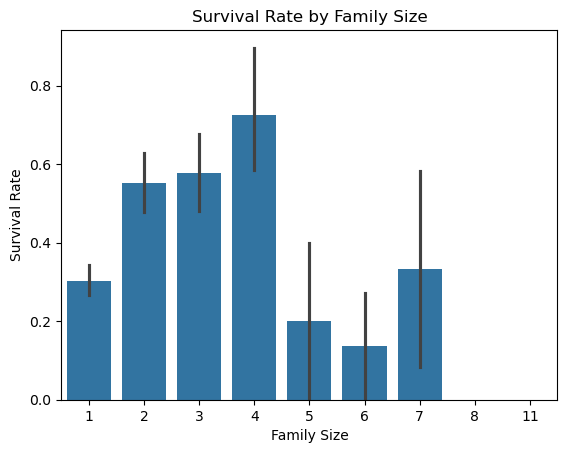

In [24]:
sns.barplot(
    data=df,
    x="FamilySize",
    y="Survived"
)

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")

plt.show()


In [25]:
df["Embarked"].value_counts()


Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

#### Survival Rate by Embarkation Port


In [27]:
df.groupby("Embarked")["Survived"].mean() * 100


Embarked
C    55.357143
Q    38.961039
S    33.695652
Name: Survived, dtype: float64

#### Survival Rate by Gender and Passenger Class


In [29]:
pd.crosstab(
    [df["Pclass"], df["Sex"]],
    df["Survived"],
    normalize="index"
) * 100


Survived               0          1
Pclass Sex                         
1      female   3.191489  96.808511
       male    63.114754  36.885246
2      female   7.894737  92.105263
       male    84.259259  15.740741
3      female  50.000000  50.000000
       male    86.455331  13.544669

## 10. Key Findings and Conclusion

### Key Findings

- The dataset contains 891 passengers and 12 columns.
- There are 177 missing values in `Age`, 687 missing values in `Cabin`, and 2 missing values in `Embarked`.
- 342 passengers survived, while 549 passengers did not survive.
- Female passengers had a much higher survival rate (approximately 74.2%) than male passengers (approximately 18.9%).
- First-class passengers had the highest survival rate (approximately 63.0%), while third-class passengers had the lowest (approximately 24.2%).
- Passengers who paid higher fares generally had better survival outcomes.
- Passengers embarking from port C had the highest survival rate among the three ports.
- Passengers traveling in small family groups generally had better survival rates than those traveling alone or in very large families.
- The analysis of gender and passenger class showed that both factors were strongly associated with survival.
- The Fare variable contains several high-value outliers, while the Age distribution contains missing values.

### Conclusion

The exploratory analysis shows that survival on the Titanic was strongly associated with factors such as gender, passenger class, and fare. Female passengers and passengers in higher classes generally had better chances of survival. Family size and embarkation port also showed differences in survival rates. Overall, the EDA helped identify important patterns, relationships, missing values, and outliers in the Titanic dataset.
